In [11]:
import numpy as np
import torch
import pandas as pd
import h5py
from src.interpolate import shift_spectra_linear
from src.ccf import compute_CCFs, get_full_ccf_analysis
from astropy.timeseries import LombScargle

/home/tliopis/Codes/exoplanets_llopis_mary_2025/venv/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 1) D'abord fixer le style de base
plt.style.use("default")  # ou un autre style si tu veux

# 2) Ensuite seulement surcharger avec tes rcParams
mpl.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "legend.fontsize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.framealpha": 0.9,
        "legend.fancybox": False,
        "figure.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.dpi": 300,
        "savefig.format": "pdf",
        "axes.grid": False,
        "grid.alpha": 0.8,
        "grid.linestyle": ":",
    }
)

In [4]:
dset_soap = np.load(
    "../data/npz_datasets/plot_dataset.npz",
)

soap_wavegrid = dset_soap["wavegrid"]
soap_spectra = dset_soap["spectra"]
soap_activity = dset_soap["activity"]
soap_template = dset_soap["template"]
soap_time_values = dset_soap["time_values"]

dset_soap_ccf_activity = np.load("../data/npz_datasets/plot_dataset_ccf_activity.npz")
dset_soap_ccf_activity_planet = np.load("../data/npz_datasets/plot_dataset_ccf_activity_planet.npz")


# Contexte scientifique

### Plot d'un spectre

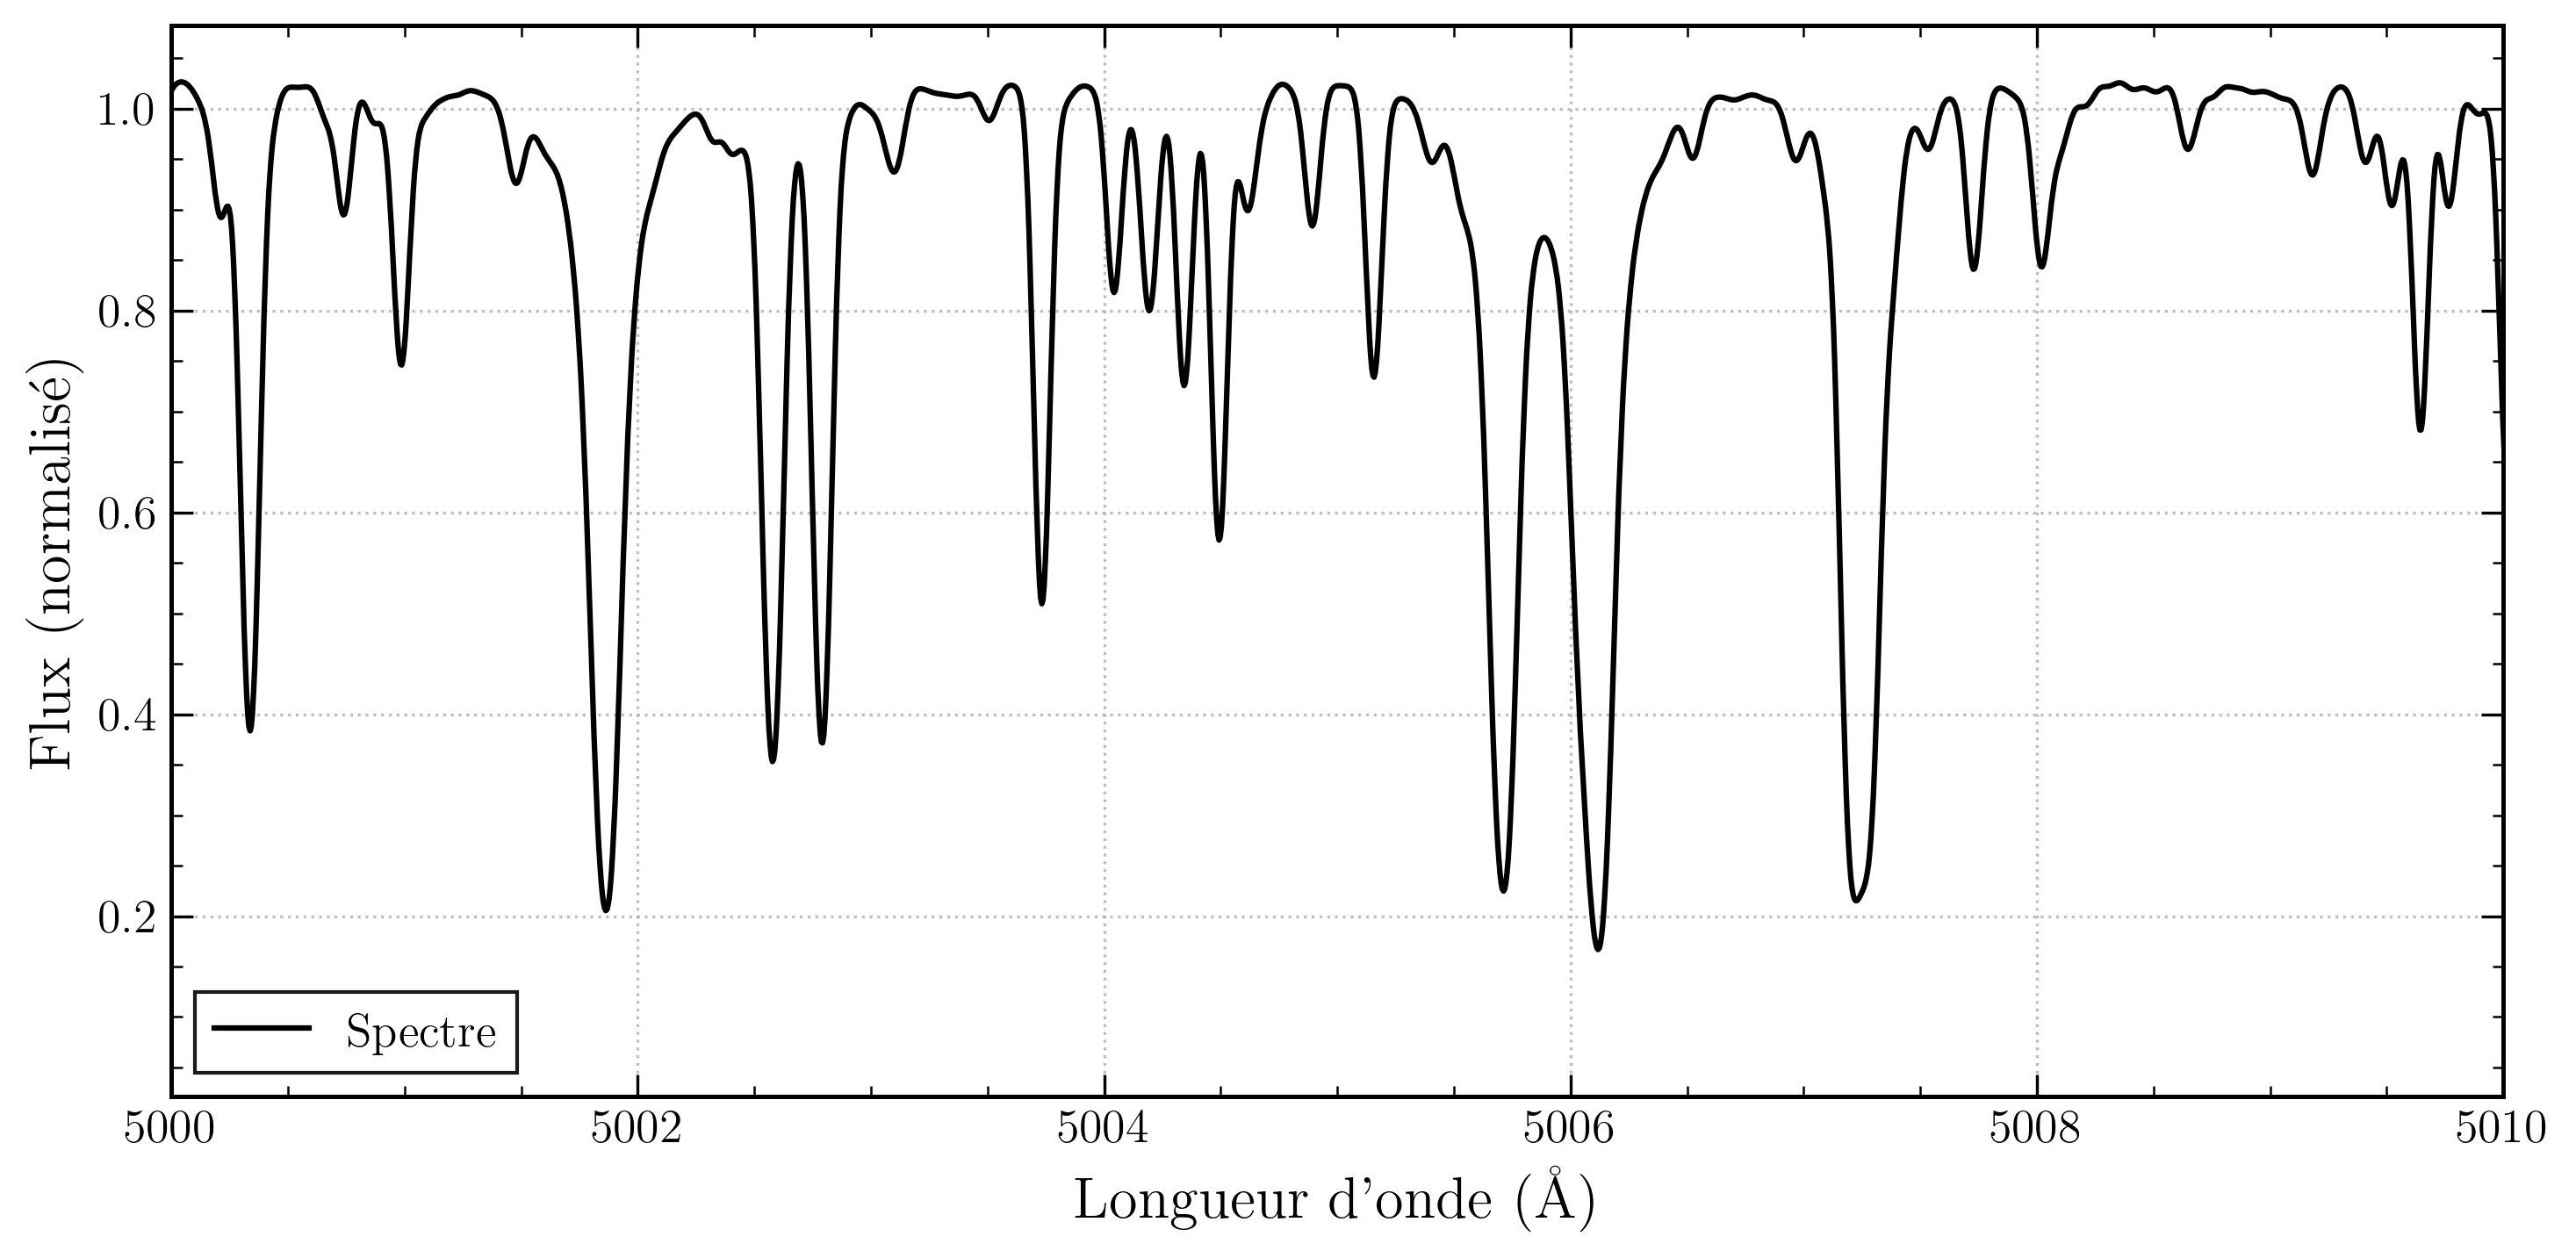

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(soap_wavegrid, soap_spectra[0, :], label="Spectre", color="black")
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5000, 5010)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/spectrum_example.png",
    dpi=300,
)
plt.show()

In [6]:
t_velocity = torch.tensor([3000]).unsqueeze(0)
t_spectrum = torch.tensor(soap_spectra[0, :]).unsqueeze(0)
t_wavegrid = torch.tensor(soap_wavegrid).unsqueeze(0)

shifted_spectrum = shift_spectra_linear(
    spectra=t_spectrum,
    velocities=t_velocity,
    wavegrid=t_wavegrid
)

shifted_spectrum = shifted_spectrum.squeeze(0).detach().numpy()

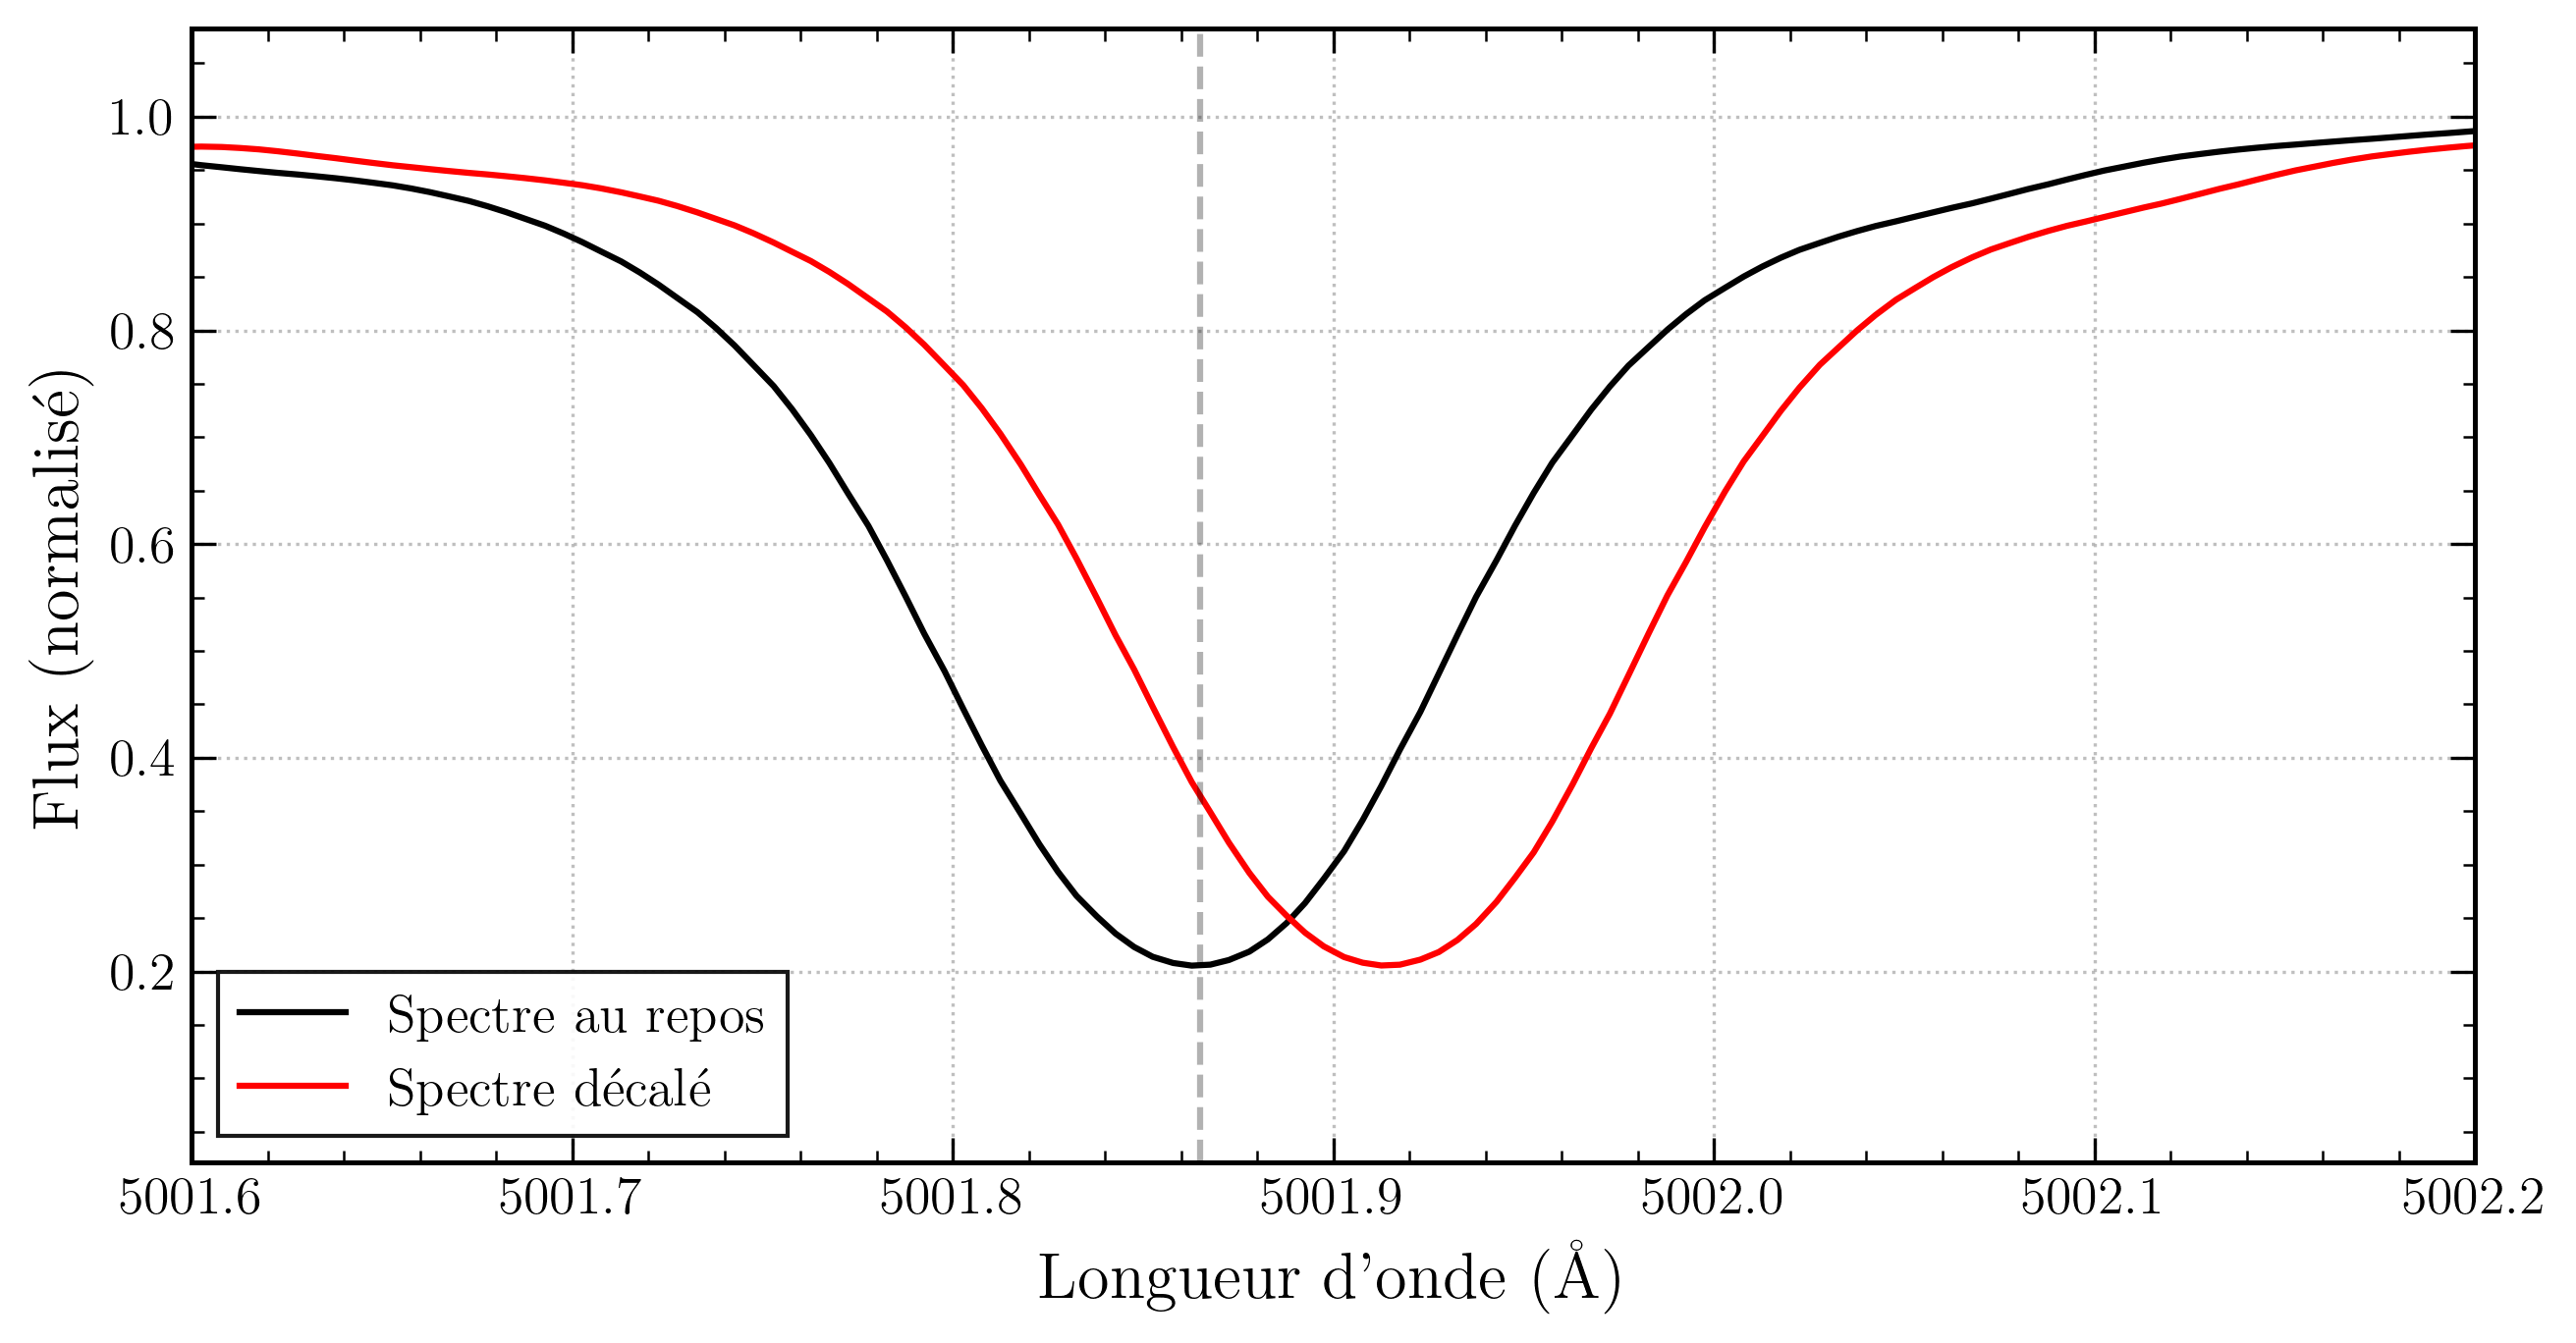

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(soap_wavegrid, soap_spectra[0, :], label="Spectre au repos", color="black")
plt.plot(soap_wavegrid, shifted_spectrum, label="Spectre décalé", color="red")
plt.axvline(
    x=5001.865,
    color="black",
    linestyle="--",
    alpha=0.3,
)
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5001.6, 5002.2)
plt.grid(alpha=0.8)
plt.legend()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/doppler_shift.png",
    dpi=300,
)
plt.show()

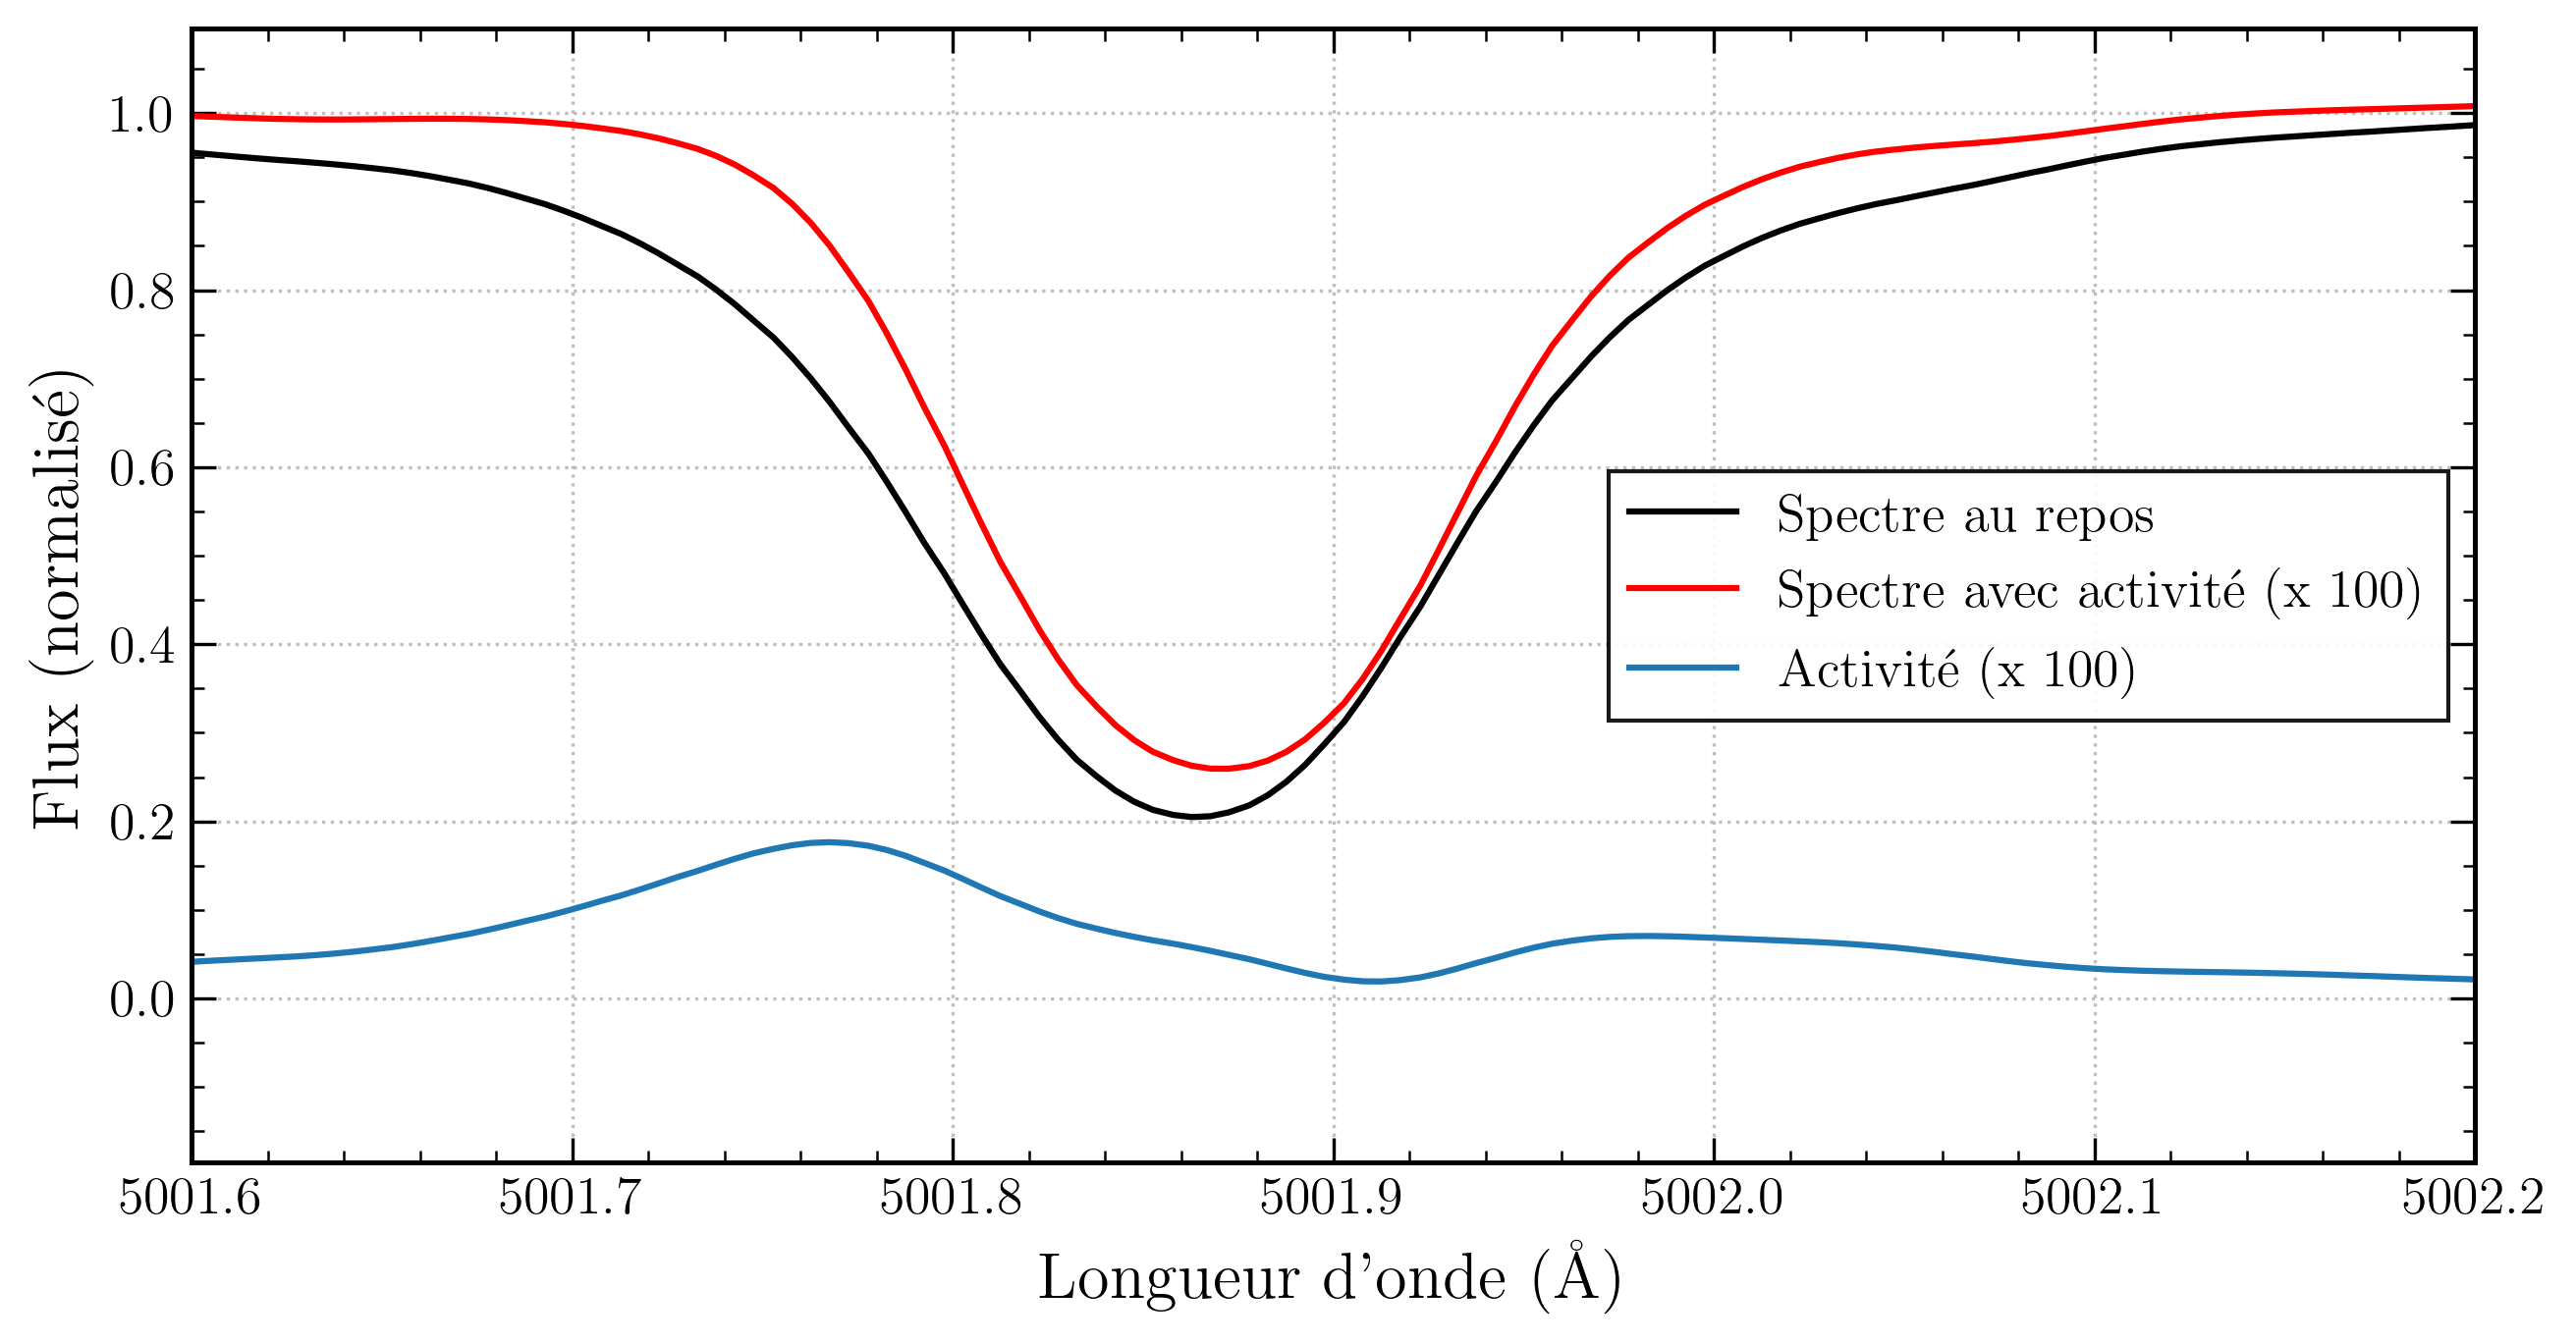

In [8]:

plt.figure(figsize=(10, 5))
plt.plot(soap_wavegrid, soap_template, label="Spectre au repos", color="black")
plt.plot(soap_wavegrid, soap_template + soap_activity[0, :] * 100, label="Spectre avec activité (x 100)", color="red")
plt.plot(
    soap_wavegrid, soap_activity[0, :] * 100, label="Activité (x 100)"
)

plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5001.6, 5002.2)
plt.grid()
plt.legend()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/activite.png",
    dpi=300,
)
plt.show()


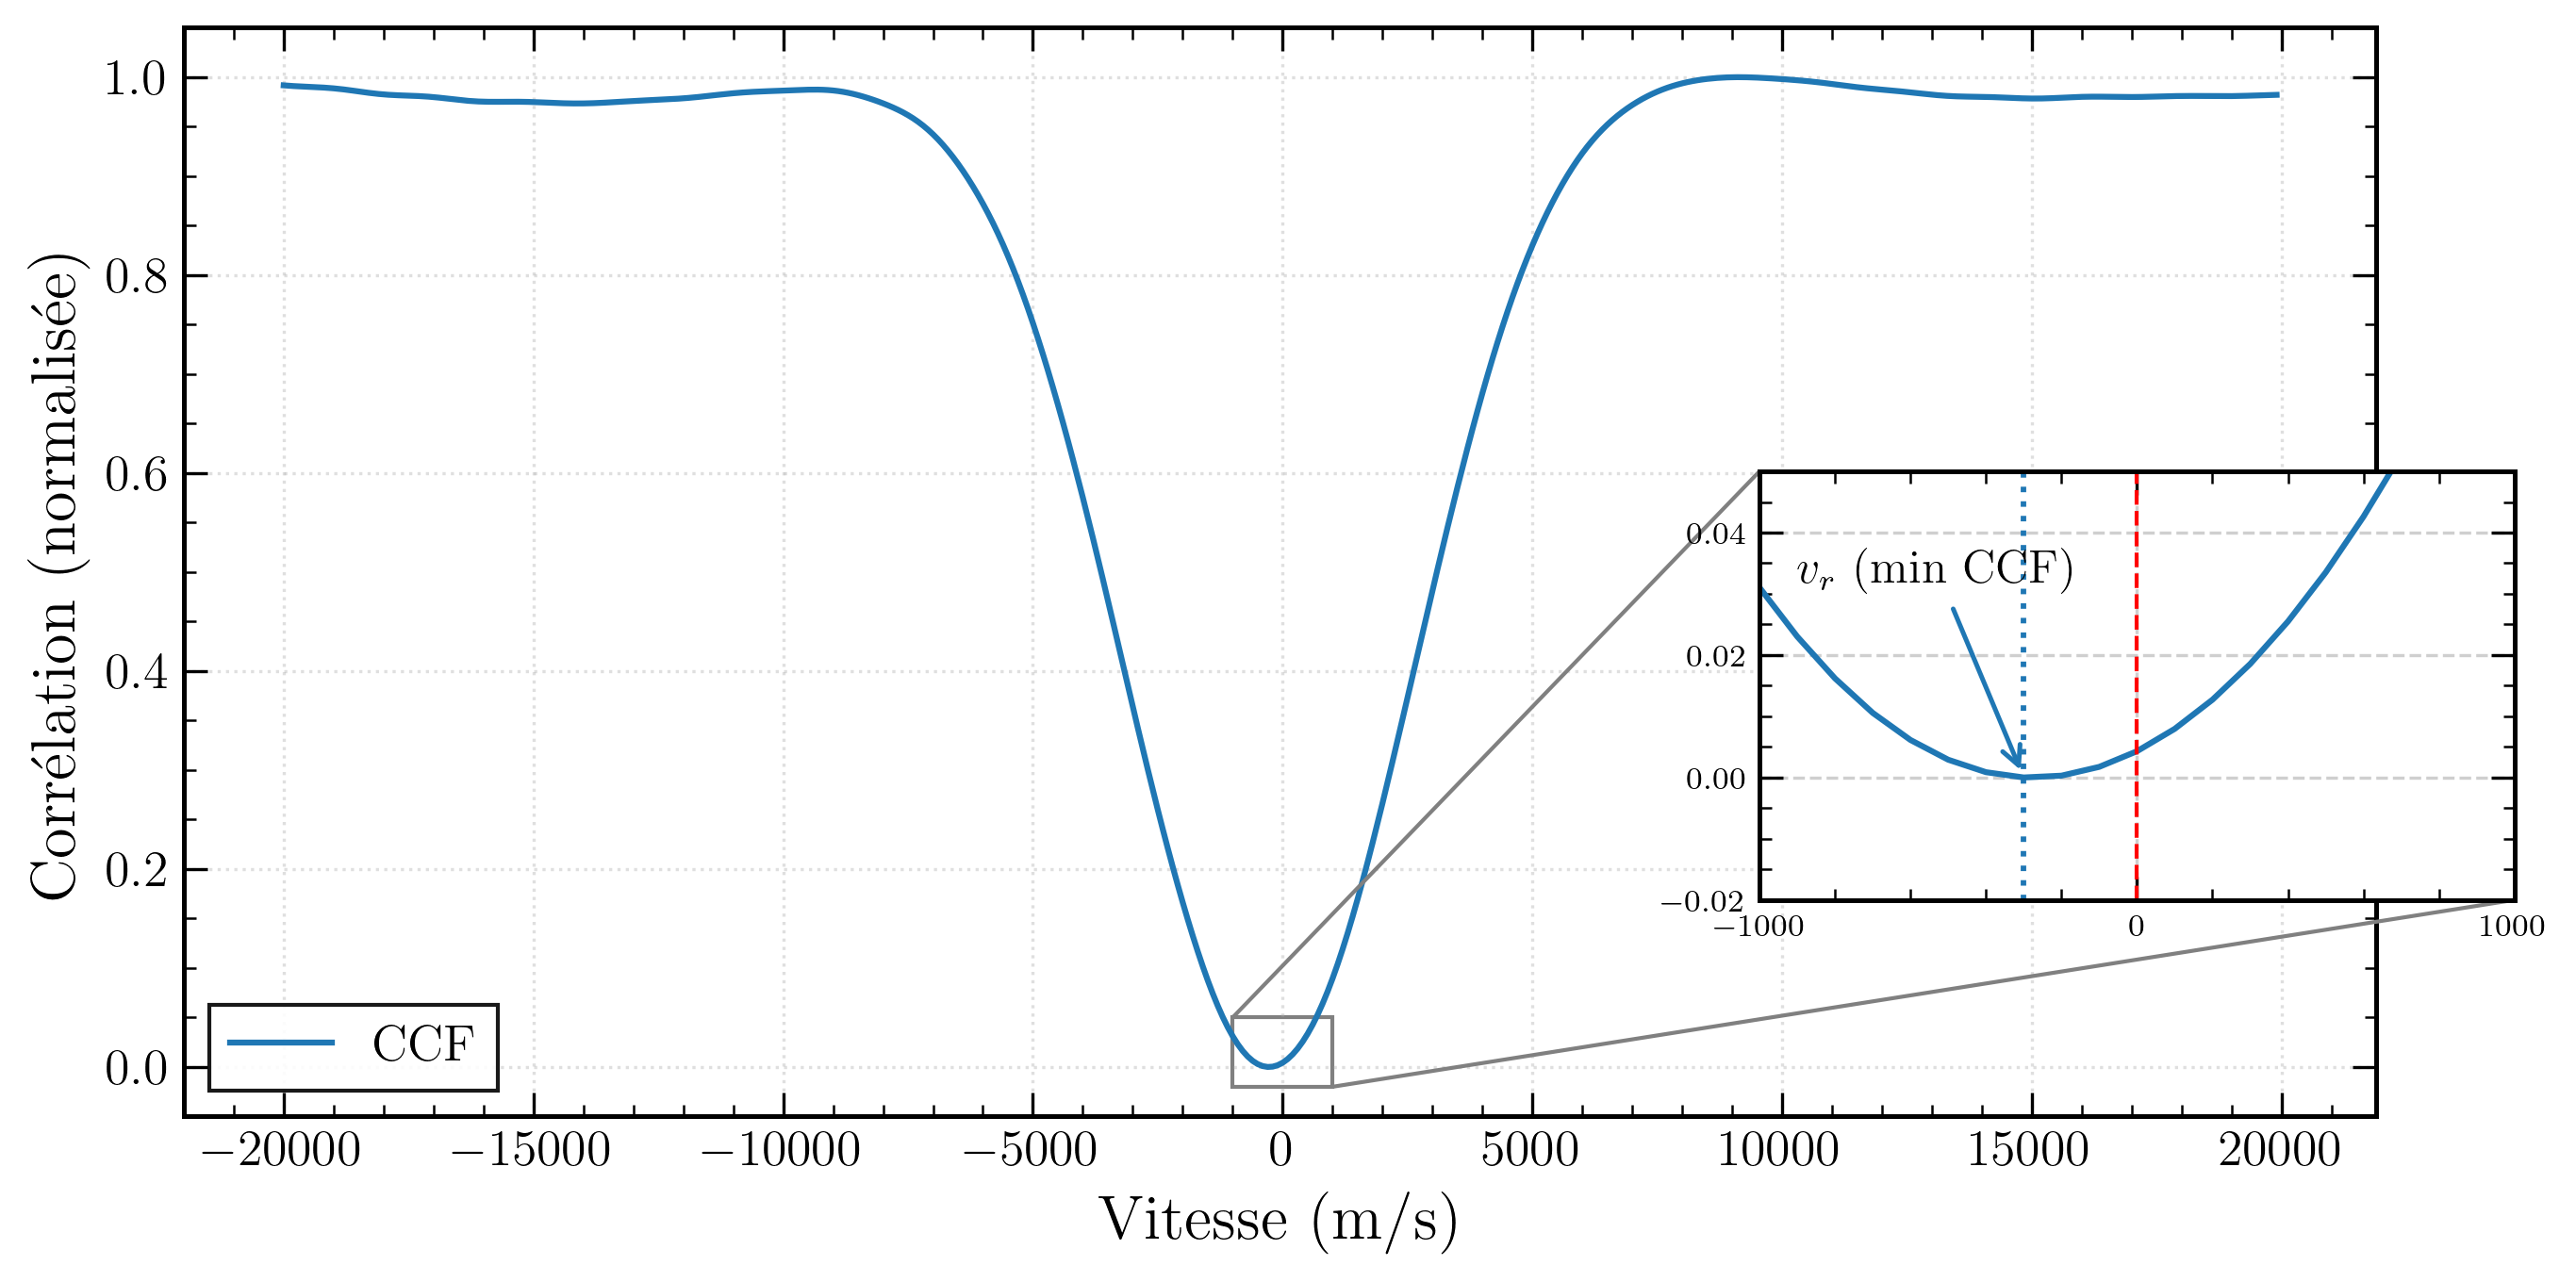

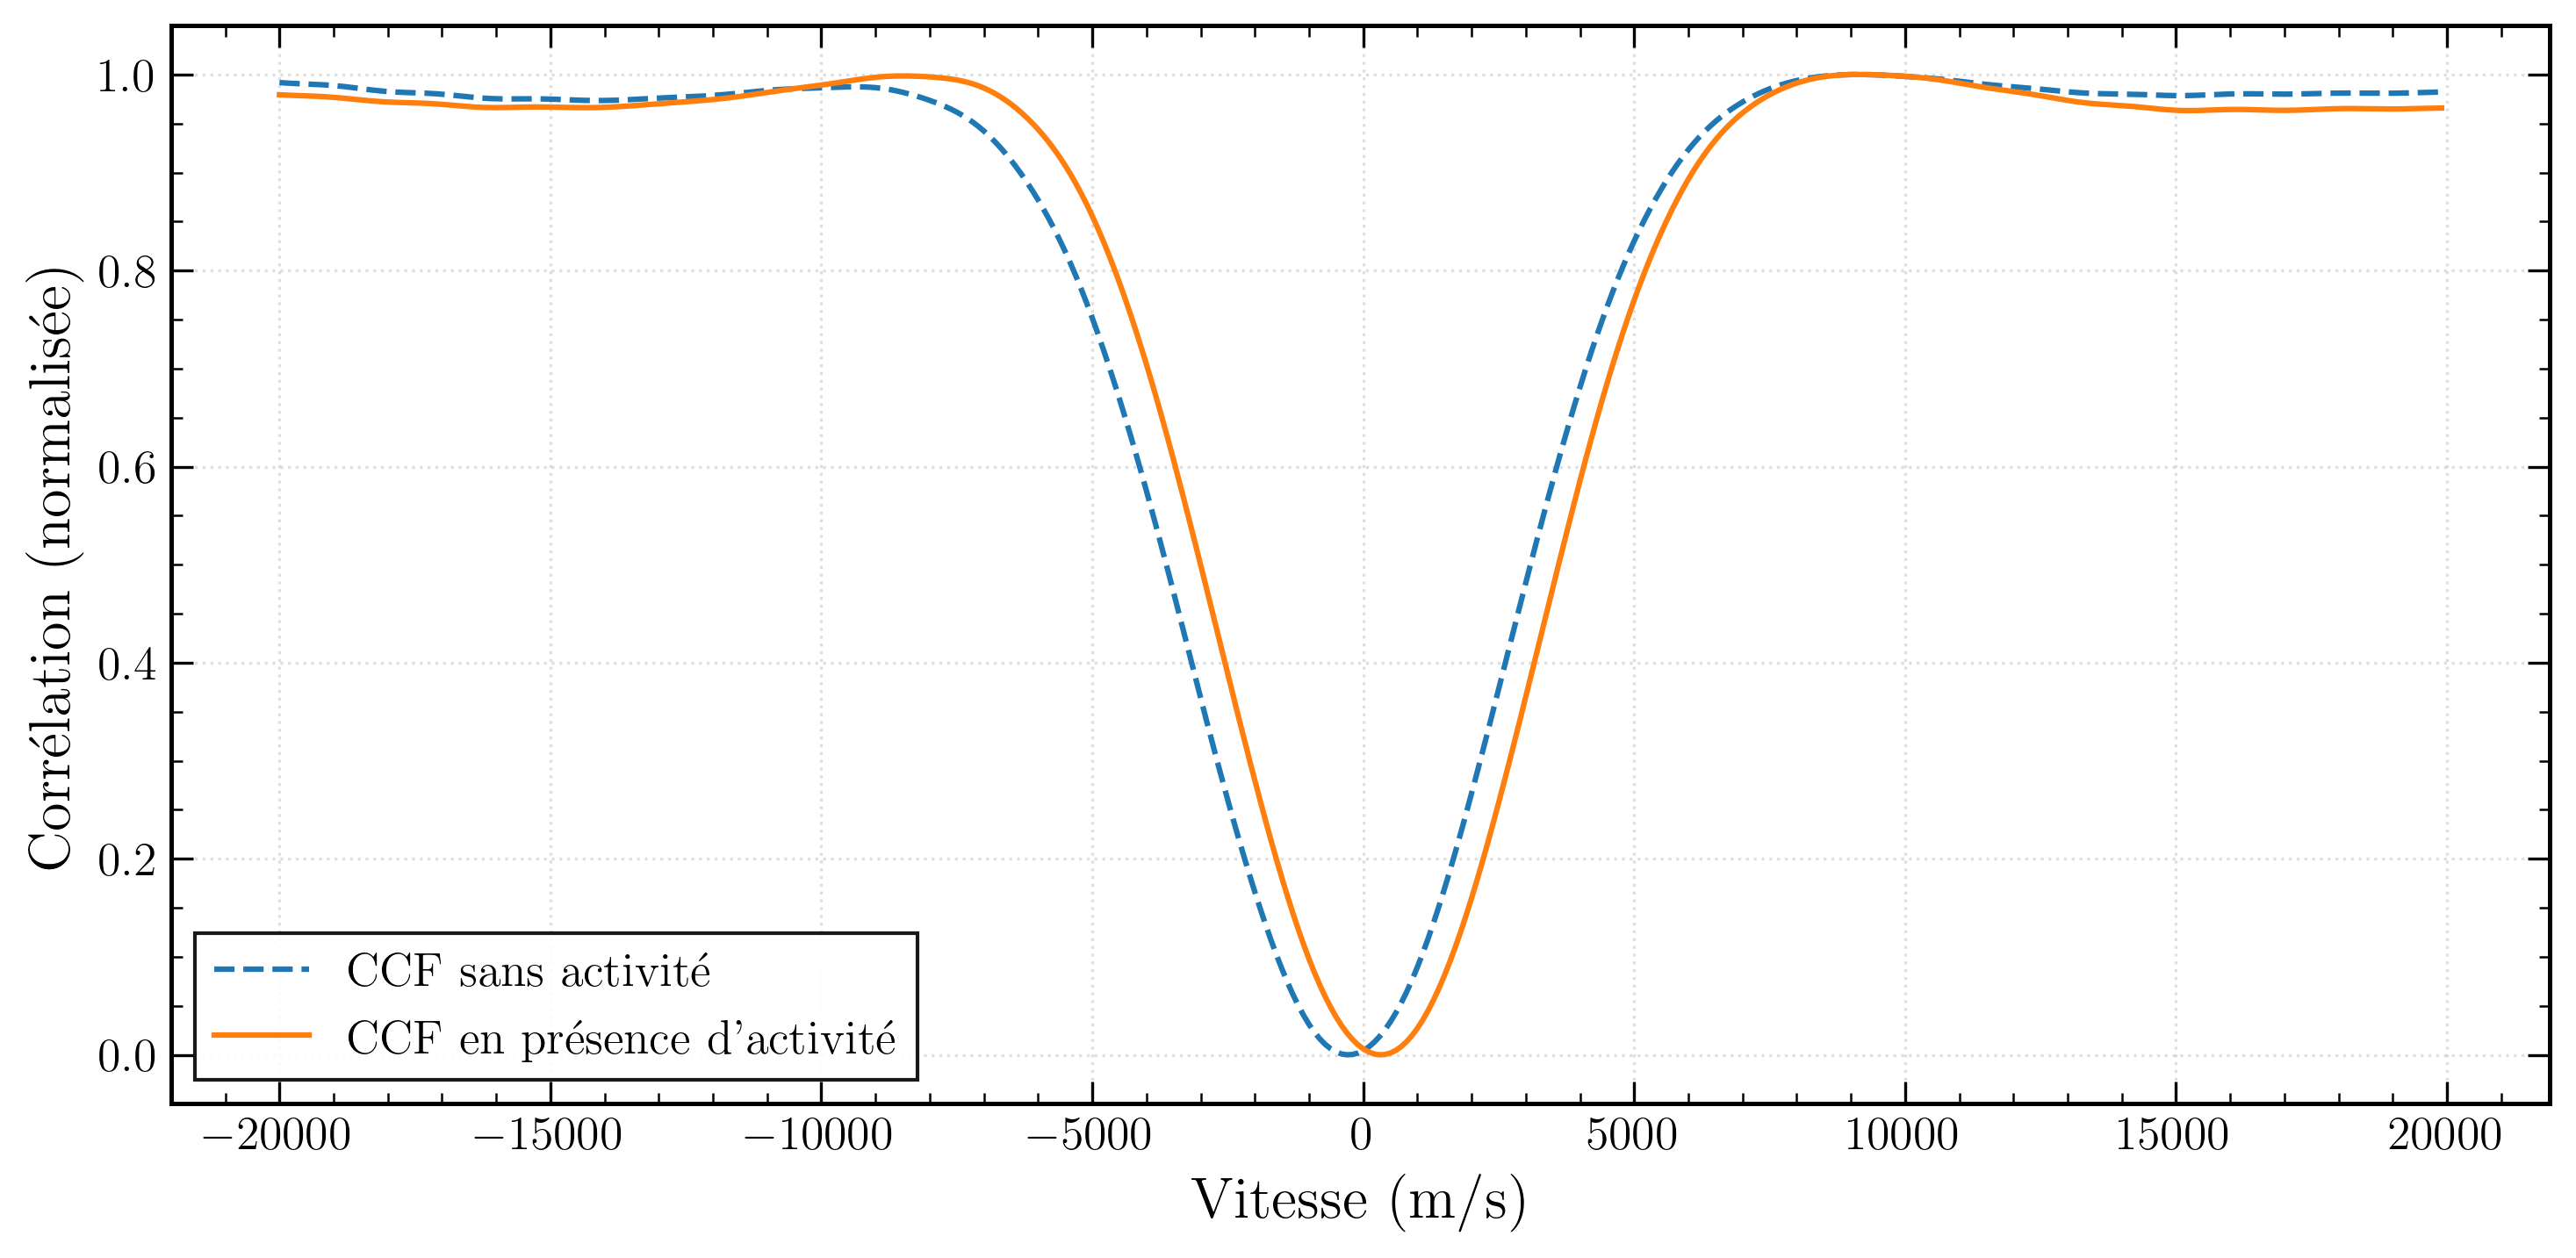

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# -----------------------------
# Préparation des données
# -----------------------------
v_grid = np.arange(-20000, 20000, 100)

tmp = dset_soap_ccf_activity["template"][None, :]
tmp_activity = (
    dset_soap_ccf_activity["activity"][0] * 100 + dset_soap_ccf_activity["template"]
)
tmp_activity = tmp_activity[None, :]

ccf = compute_CCFs(
    spectra=tmp,
    wavegrid=dset_soap_ccf_activity["wavegrid"],
    v_grid=v_grid,
    window_size_velocity=820,
)[0]

ccf_activity = compute_CCFs(
    spectra=tmp_activity,
    wavegrid=dset_soap_ccf_activity["wavegrid"],
    v_grid=v_grid,
    window_size_velocity=820,
)[0]

# -----------------------------
# Figure 1 : CCF + inset
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Courbe principale
ax.plot(v_grid, ccf, label="CCF")
ax.set_xlabel("Vitesse (m/s)")
ax.set_ylabel("Corrélation (normalisée)")
ax.grid(True, alpha=0.4)
ax.legend()

# Vitesse correspondant au minimum de la CCF
v_min_idx = np.argmin(ccf)
v_r = v_grid[v_min_idx]
ccf_min = ccf[v_min_idx]

# --- Sous-fenêtre (inset) agrandie ---
#   -> on augmente légèrement la surface du zoom
axins = inset_axes(
    ax,
    width="82%",  # plus grand qu'avant
    height="82%",  # plus grand qu'avant
    bbox_to_anchor=(0.70, 0.15, 0.42, 0.48),  # (x0, y0, width, height) en coords d'ax
    bbox_transform=ax.transAxes,
    loc="upper left",
    borderpad=0.8,
)

# Courbe dans l'inset
axins.plot(v_grid, ccf, label="CCF (zoom)")

# Zoom sur la zone du minimum
x1, x2 = -1000, 1000
y1, y2 = ccf_min - 0.02, ccf_min + 0.05
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Grille + lignes verticales (v=0 et v_r)
axins.grid(True, linestyle="--", alpha=0.6)
axins.axvline(0, color="red", linestyle="--", linewidth=1, label="v = 0")
min_line = axins.axvline(v_r, color="C0", linestyle=":", linewidth=1.4, label="min CCF")

# Annotation propre avec flèche sur le minimum
axins.annotate(
    r"$v_r$ (min CCF)",
    xy=(v_r, ccf_min),  # point à annoter
    xytext=(v_r - 600, ccf_min + 0.03),  # position du texte
    textcoords="data",
    arrowprops=dict(arrowstyle="->", lw=1.2, color="C0"),
    ha="left",
    va="bottom",
    fontsize=12,
)

# Ticks de l'inset
axins.set_xticks([-1000, 0, 1000])
axins.tick_params(labelsize=8)

# Légende de l'inset (labels visibles)

# Cadre reliant zone zoomée
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/ccf_example.png",
    dpi=300,
)
plt.show()

# -----------------------------
# Figure 2 : CCF vs CCF activité
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(v_grid, ccf, label="CCF sans activité", linestyle="--")
plt.plot(v_grid, ccf_activity, label="CCF en présence d'activité")
plt.xlabel("Vitesse (m/s)")
plt.ylabel("Corrélation (normalisée)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/ccf_acti.png",
    dpi=300,
)
plt.show()


In [10]:
res = get_full_ccf_analysis(
    spectra=dset_soap_ccf_activity_planet["spectra"],
    wavegrid=dset_soap_ccf_activity_planet["wavegrid"],
    v_grid=np.arange(-20000, 20000, 250),
    window_size_velocity=820,
)

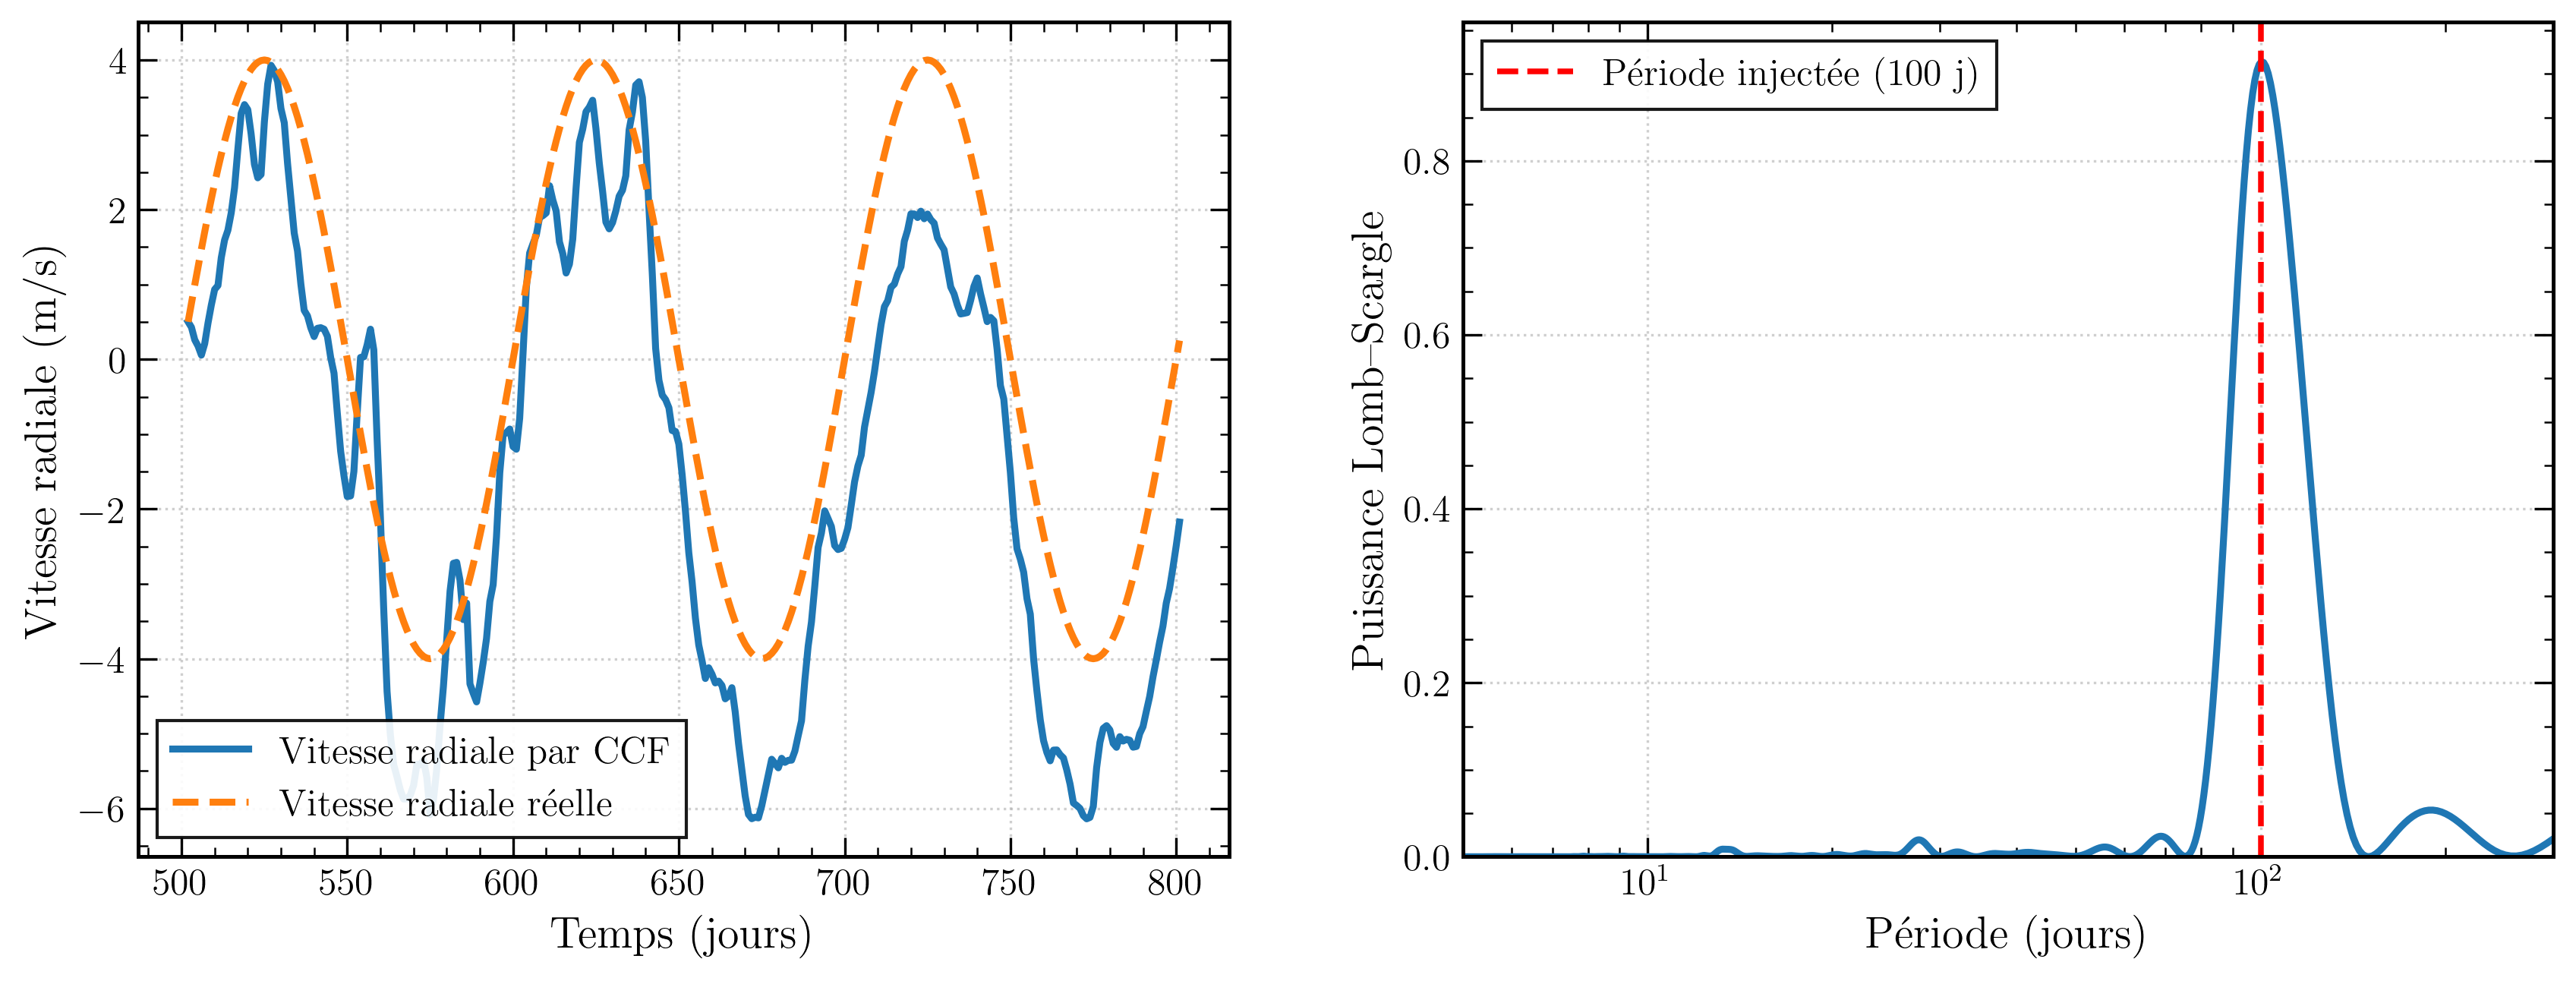

In [11]:
# =========================
# PLOT CONDENSÉ (2 PANNEAUX)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# ---- style local ----
plot_style = {
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.framealpha": 0.9,
    "legend.fancybox": False,
    "figure.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "savefig.format": "pdf",
    "axes.grid": False,
}

# --------- Données ---------
time = dset_soap_ccf_activity_planet["time_values"]
rv_ccf = res["rv"]
rv_true = dset_soap_ccf_activity_planet["v_true"]
rv_ccf_centered = rv_ccf - np.mean(rv_ccf)

# --------- Lomb–Scargle ---------
min_period, max_period = 2, 500
frequency = np.linspace(1 / max_period, 1 / min_period, 6000)
ls = LombScargle(time, rv_ccf_centered)
power = ls.power(frequency)
periods = 1 / frequency

# =========================
# Figure combinée
# =========================
with plt.rc_context(plot_style):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

    # --- (a) Série temporelle RV ---
    ax = axes[0]
    ax.plot(
        time, rv_ccf - rv_ccf[0] + rv_true[0], label="Vitesse radiale par CCF", lw=2.2
    )
    ax.plot(time, rv_true, "--", label="Vitesse radiale réelle", lw=2.2)
    ax.set_xlabel("Temps (jours)")
    ax.set_ylabel("Vitesse radiale (m/s)")
    ax.legend(loc="best")
    ax.grid(True, ls=":", alpha=0.6)

    # --- (b) Périodogramme LS ---
    ax = axes[1]
    ax.plot(periods, power, lw=2.2)
    ax.axvline(100, color="r", ls="--", lw=1.8, label="Période injectée (100 j)")
    ax.set_xscale("log")
    ax.set_xlim(5, 300)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Période (jours)")
    ax.set_ylabel("Puissance Lomb–Scargle")
    ax.legend(loc="upper left")
    ax.grid(True, ls=":", alpha=0.6)

    # --- Ajustement global ---
    plt.tight_layout(w_pad=3.0)
    plt.savefig(
        "./plots_rapport/contexte_scientifique/rv_plus_periodogram_combined.png",
        bbox_inches="tight",
    )
    plt.show()

/tmp/ipykernel_41958/2427374879.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yva = pd.read_csv(filepath, delim_whitespace=True, comment="#")


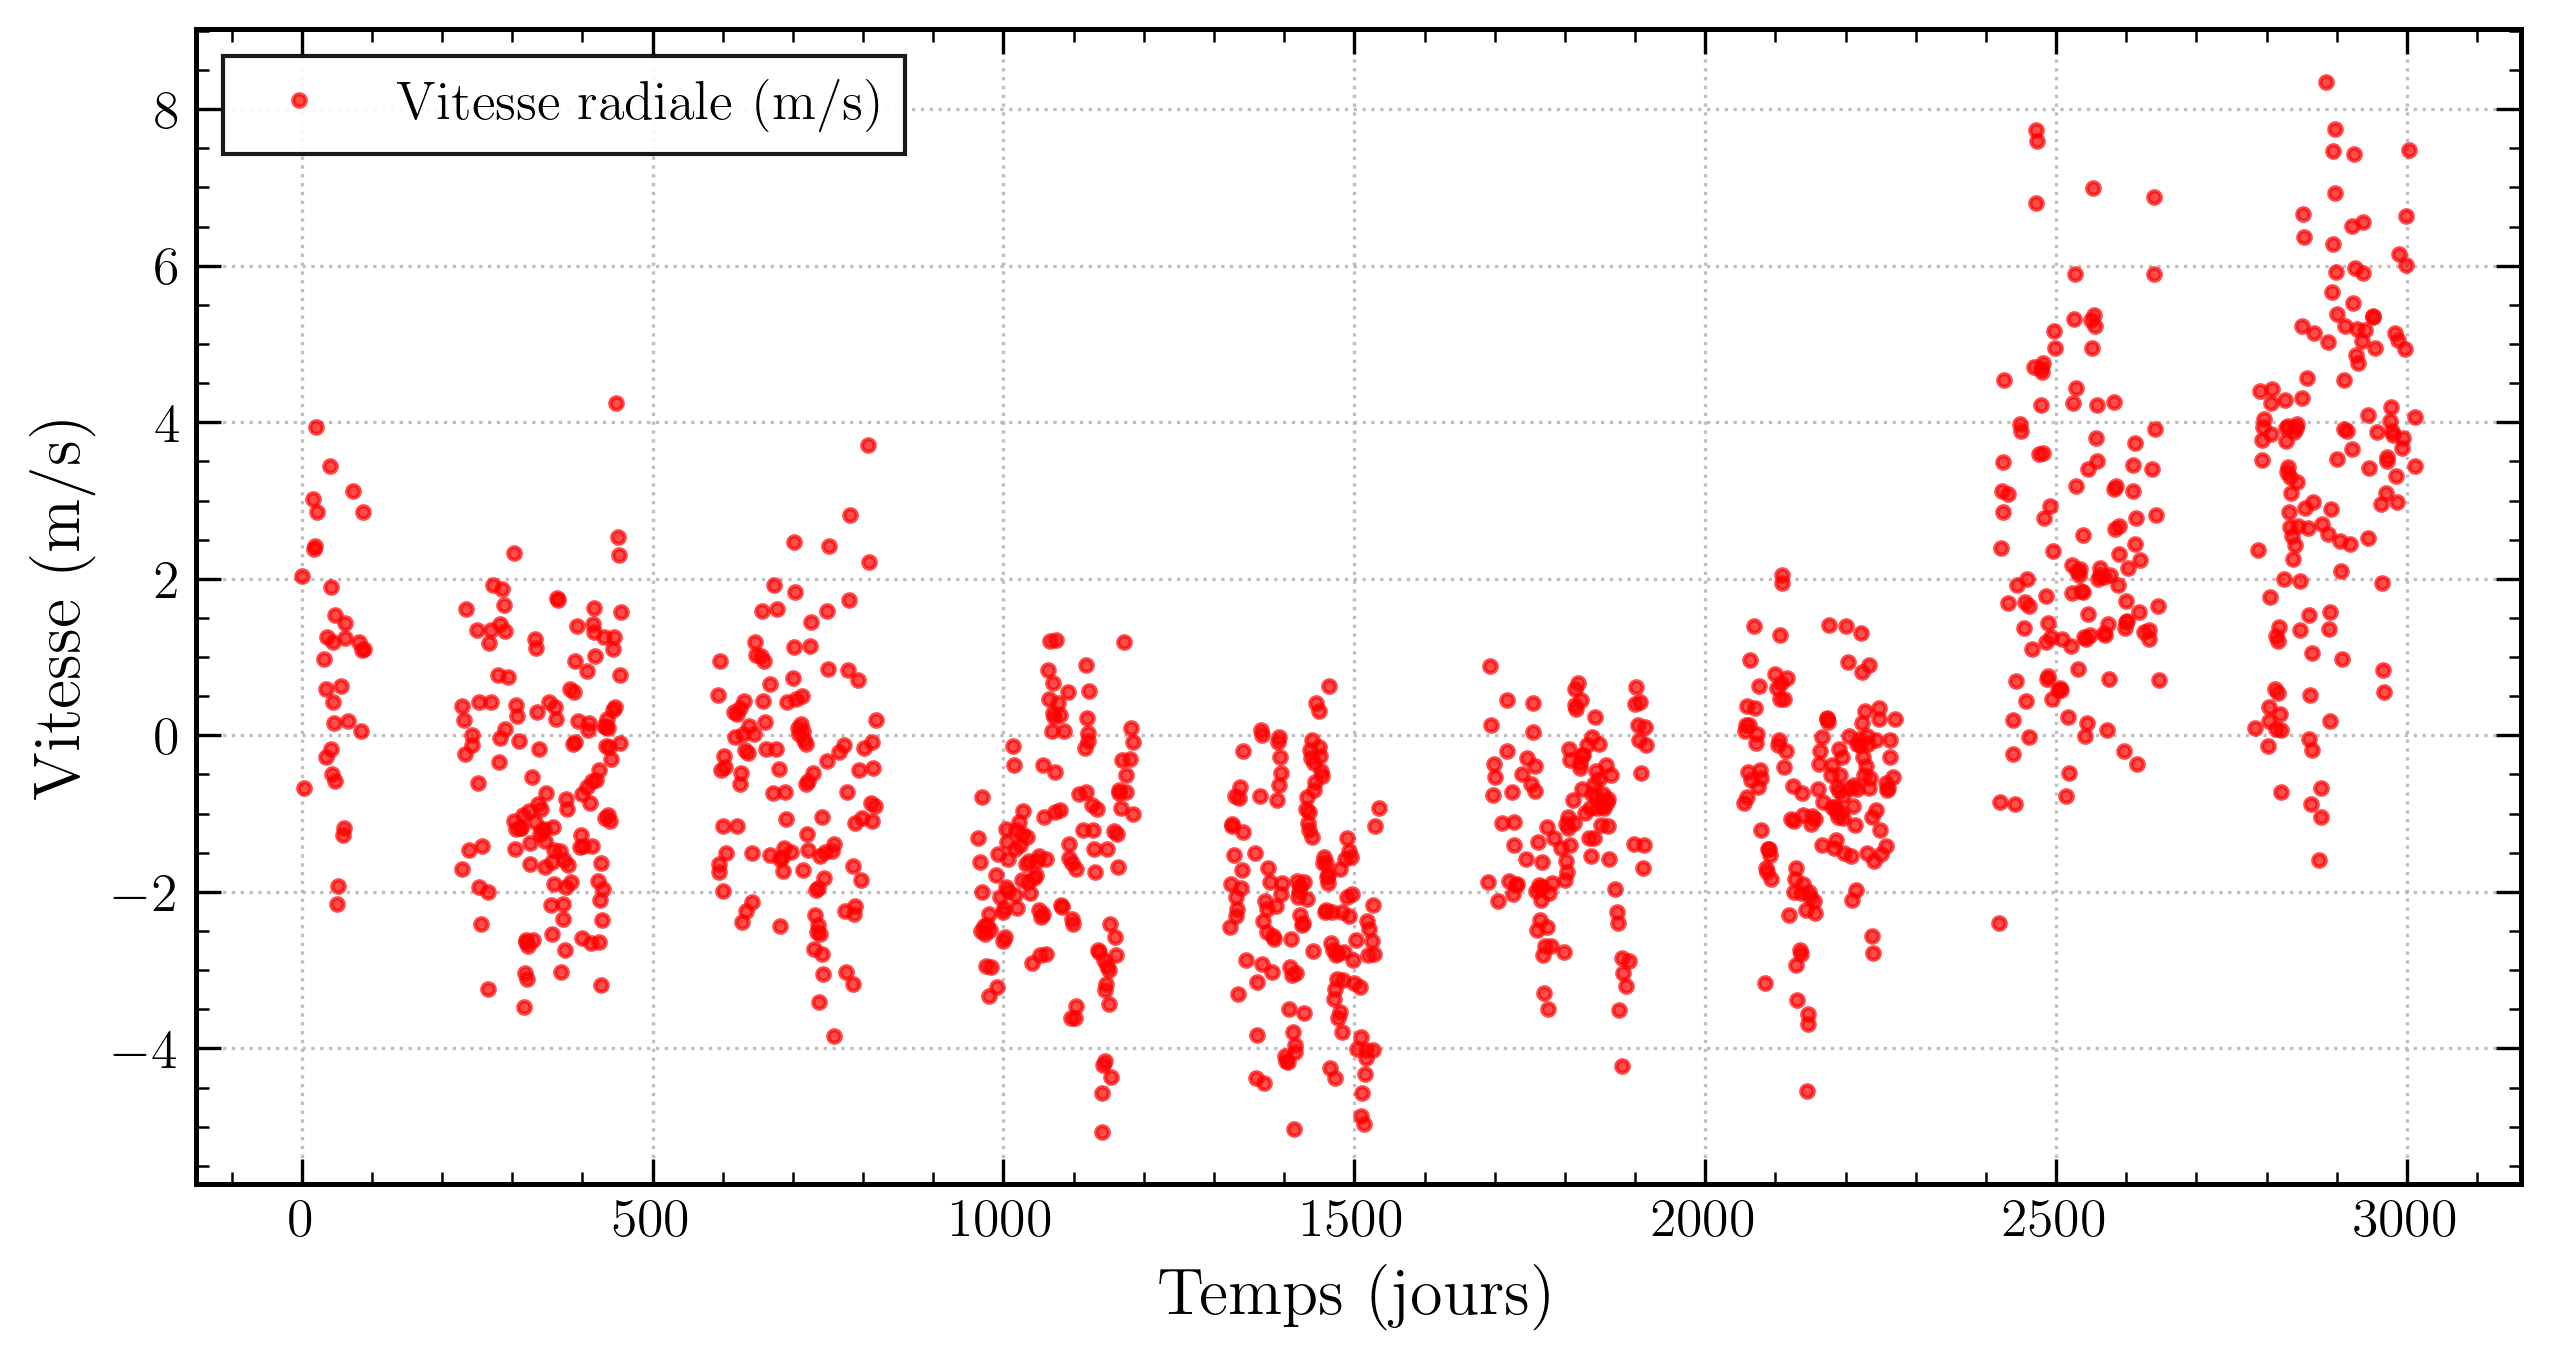

In [12]:
filepath="/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57001_E61001_planet-FallChallenge1/STAR1136_DACE_YVA.rdb"
# --- Charger YV0 et YVA ---
df_yva = pd.read_csv(filepath, delim_whitespace=True, comment="#")

df_yva = df_yva.iloc[1:]  # enlever la premiere ligne

df_yva = df_yva.iloc[:, :-1]  # enlever la derniere colonne

df_yva = df_yva.astype({"vrad": "float32", "svrad": "float32", "jdb": "float32"})

rvA = (df_yva["vrad"] - df_yva["vrad"].mean()) * 1000
timeA = df_yva["jdb"] - df_yva["jdb"].iloc[0]

mask = rvA <= 40
rvA = rvA[mask]
timeA = timeA[mask]

# --- Tracer ---
plt.figure(figsize=(10, 5))
plt.errorbar(
    timeA,
    rvA,
    fmt="o",
    ms=3,
    color="red",
    alpha=0.7,
    label="Vitesse radiale (m/s)",
)

plt.xlabel("Temps (jours)")
plt.ylabel("Vitesse (m/s)")
plt.grid(alpha=0.8)
plt.legend()
plt.savefig("./plots_rapport/contexte_scientifique/rv_timeseries_example_irregular.png")
plt.show()


In [1]:
from src.modeling.train import load_experiment_checkpoint

ckpt = load_experiment_checkpoint("../experiments/grid_search/soapgpu_ns3292_5000-5050_dx2_sm3_nonoise__baseline/models/aestra_final.pth", dataset_filepath="../data/npz_datasets/exps_rapport/soapgpu_ns3292_5000-5050_dx2_sm3_nonoise__baseline.npz", device="cpu")

ckpt_dset = ckpt["dataset"]
ckpt_model = ckpt["model"]

[11:09:00] 📂 Loading experiment checkpoint:                                                           ]8;id=20961;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py\train.py]8;;\:]8;id=860876;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py#194\194]8;;\
           ../experiments/grid_search/soapgpu_ns3292_5000-5050_dx2_sm3_nonoise__baseline/models/aestra             
           _final.pth                                                                                              

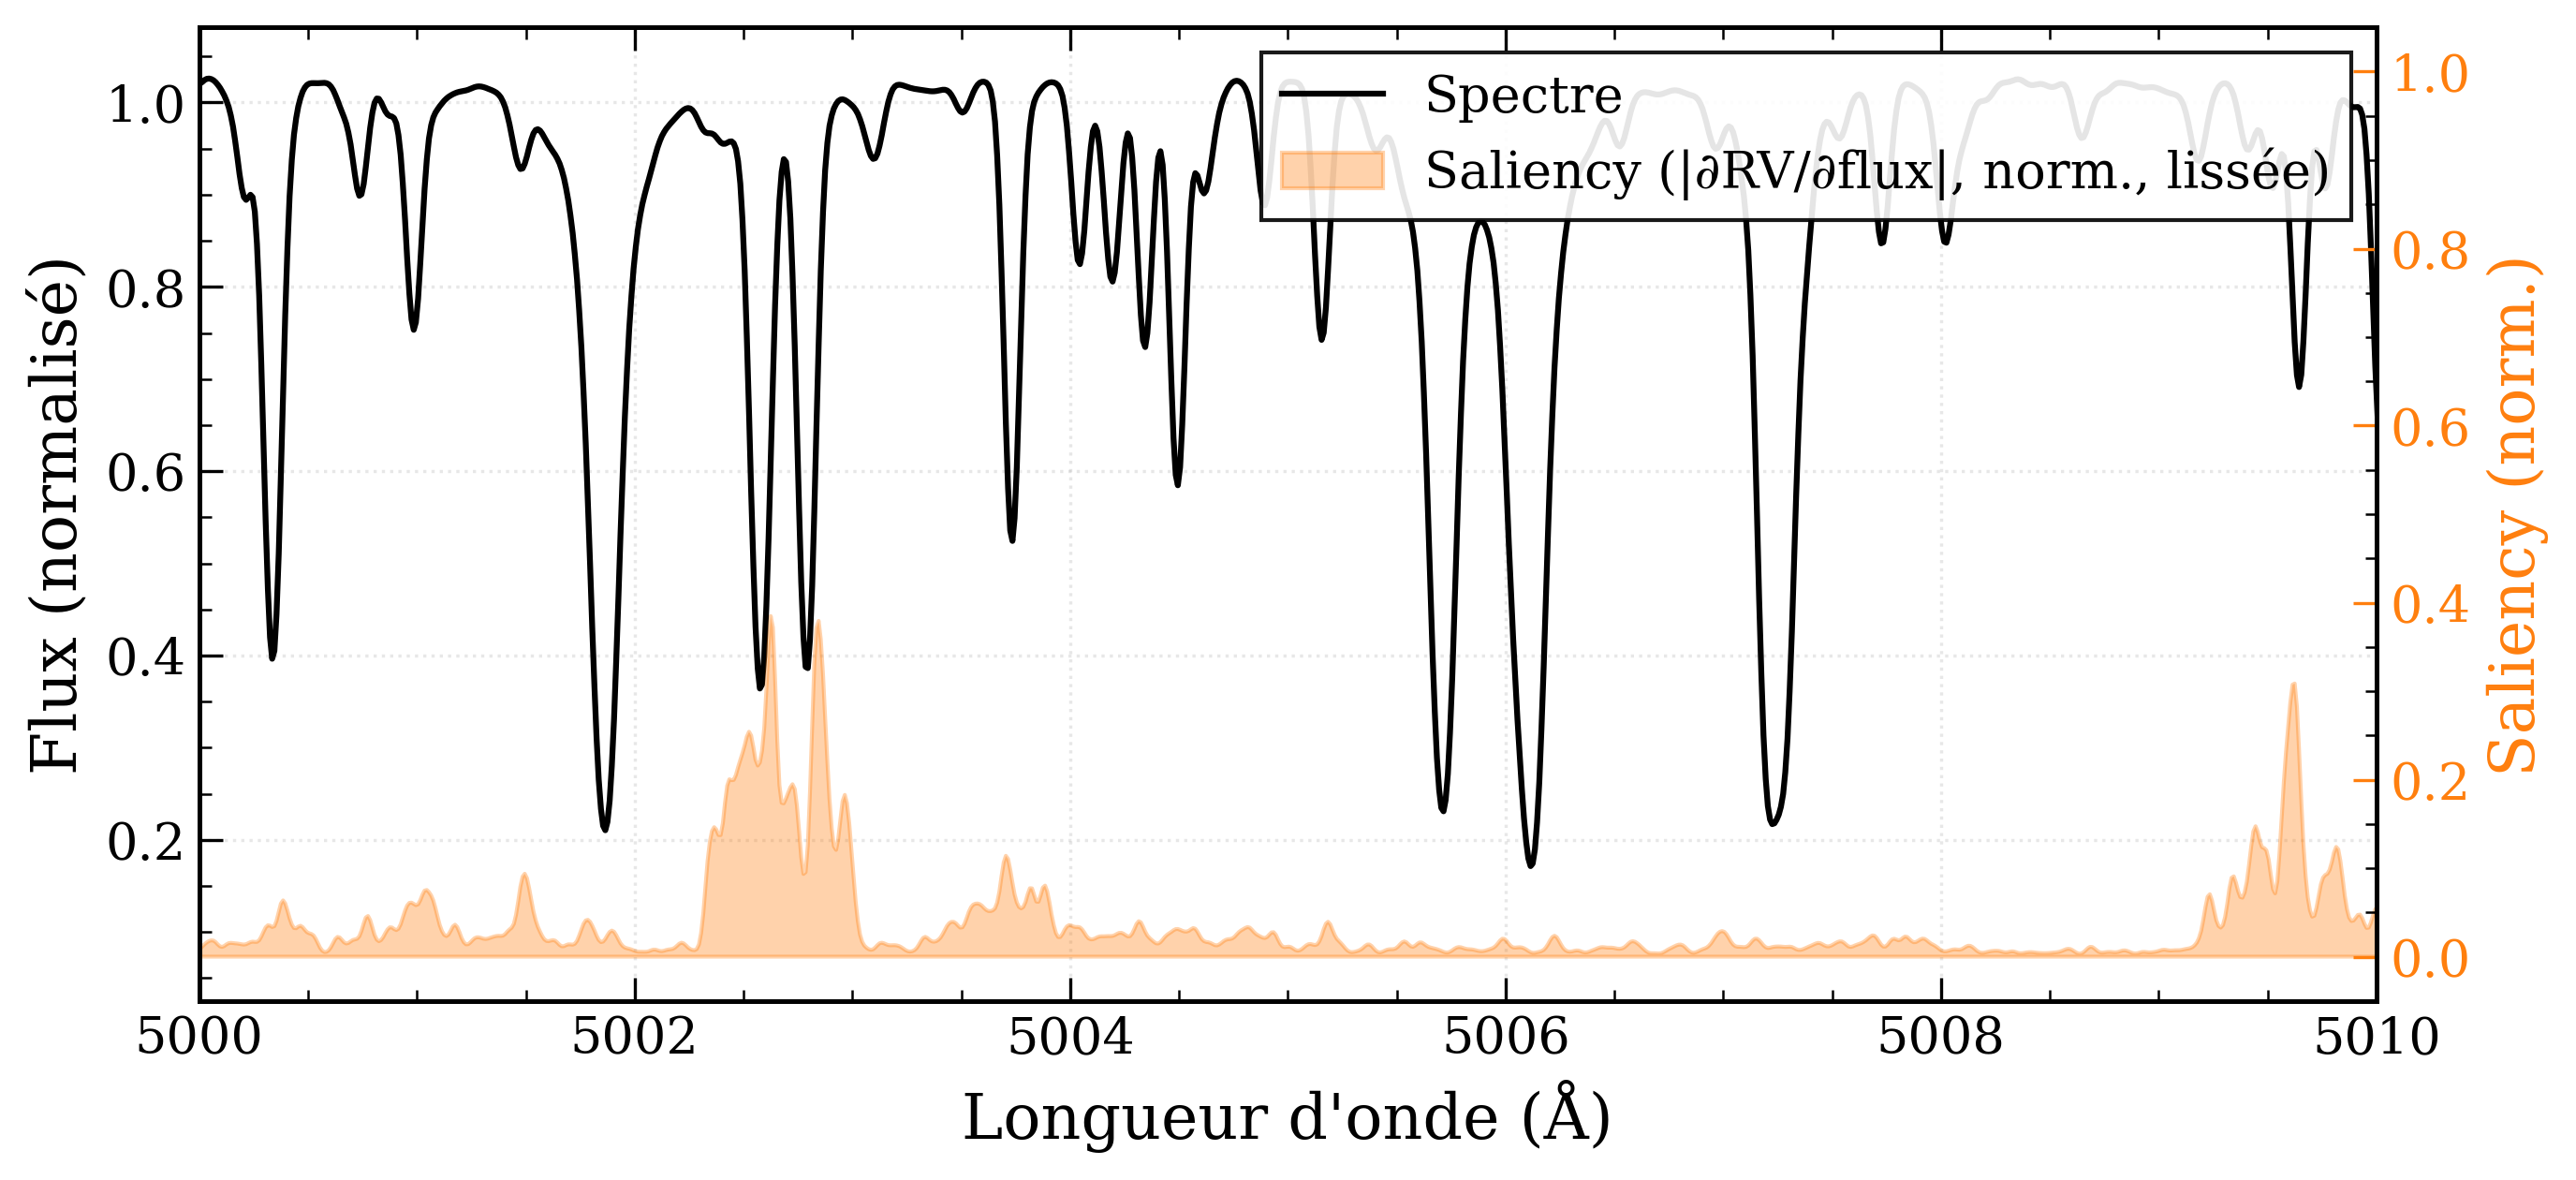

In [26]:
from src.dataset import generate_collate_fn
from torch.utils.data import DataLoader
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

# Préparer DataLoader
collate_fn = generate_collate_fn(ckpt_dset)
dataloader = DataLoader(ckpt_dset, batch_size=32, shuffle=True, collate_fn=collate_fn)

# Modèle en évaluation sur CPU
ckpt_model.eval()
device = torch.device("cpu")
ckpt_model.to(device)

# Récupérer un batch et un spectre quelconque
batch = next(iter(dataloader))
batch_yobs, batch_yaug, batch_voffset_true, batch_wavegrid, *_ = batch
batch_yobs = batch_yobs.to(device)
batch_wavegrid = batch_wavegrid.to(device)

idx = 0  # on prend le premier spectre du batch
y = batch_yobs[idx:idx+1].detach().clone().requires_grad_(True)  # [1, P]
wave = batch_wavegrid[idx].detach().cpu().numpy()

# Passage par la tête RV (rvestimator) et estimation RV
ckpt_model.zero_grad()
robs = y - ckpt_model.b_obs.unsqueeze(0).to(y.device)  # x d'entrée de la tête RV
v_pred = ckpt_model.rvestimator(robs)  # [1]
rv_value = float(v_pred.detach().cpu().numpy()[0])

# Saliency: |d(RV)/d(flux)| par pixel
v_pred.sum().backward()
saliency = y.grad.detach().cpu().numpy()[0]
saliency = np.abs(saliency)

# --- Lissage léger de la saliency (Gaussien) ---
# sigma en pixels (ajuste si nécessaire)
sigma_pix = 2.0
if sigma_pix is not None and sigma_pix > 0:
    win = int(max(3, int(8 * sigma_pix) + 1))
    x = np.arange(win) - (win - 1) / 2.0
    kern = np.exp(-(x ** 2) / (2.0 * sigma_pix ** 2))
    kern = kern / np.sum(kern)
    saliency = np.convolve(saliency, kern, mode="same")

# Renormaliser pour affichage
if np.max(saliency) > 0:
    saliency = saliency / np.max(saliency)

spectrum = y.detach().cpu().numpy()[0]

# Tracé: spectre + saliency (normalisée) sur la même figure
# Désactiver temporairement LaTeX pour cette figure pour éviter les erreurs de rendu
with plt.rc_context({"text.usetex": False}):
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    ax1.plot(wave, spectrum, color="black", label="Spectre")
    ax1.set_xlabel("Longueur d'onde (Å)")
    ax1.set_ylabel("Flux (normalisé)")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.fill_between(
        wave,
        0,
        saliency,
        color="tab:orange",
        alpha=0.35,
        label="Saliency (|∂RV/∂flux|, norm., lissée)",
    )
    ax2.set_ylabel("Saliency (norm.)", color="tab:orange")
    ax2.tick_params(axis="y", colors="tab:orange")

    # Légende combinée
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    # ASCII-only title to be safe
    # ax1.set_title(f"RV estimee = {rv_value:.2f} m/s + saliency map (sigma={sigma_pix})")
    ax1.set_xlim(5000, 5010)

    # Sauvegarde optionnelle
    outdir = "./plots_rapport/aestra"
    os.makedirs(outdir, exist_ok=True)
    plt.savefig("./plots_rapport/contexte_scientifique/spectrum_with_saliency.png", dpi=300)
    plt.show()

In [ ]:
from src.modeling.train import load_experiment_checkpoint

ckpt = load_experiment_checkpoint(
    "../experiments/vrac/baseline_1000_spectra_brest_true/models/aestra_final.pth",
    dataset_filepath="../data/npz_datasets/soapgpu_ns1000_5000-5050_p100_k0p3_phi0_cubic.npz",
    device="cpu",
)

ckpt_dset = ckpt["dataset"]
ckpt_model = ckpt["model"]


# Préparer DataLoader
collate_fn = generate_collate_fn(ckpt_dset)
dataloader = DataLoader(ckpt_dset, batch_size=32, shuffle=True, collate_fn=collate_fn)

# Modèle en évaluation sur CPU
ckpt_model.eval()
device = torch.device("cpu")
ckpt_model.to(device)

all_s = []
for batch in dataloader:
    (
            batch_yobs,
            batch_yaug,
            batch_voffset_true,
            batch_wavegrid,
            batch_weights_fid,
            batch_indices,
            batch_yact_true,
            batch_activity_proxies_norm,
        ) = batch
    batch_yobs_prime, batch_yact, _, s, s_aug = ckpt_model.get_spender_pred(
        batch_yobs=batch_yobs,
        batch_yaug=batch_yaug,
        batch_wavegrid=batch_wavegrid,
        batch_vobs_pred=batch_vobs_pred,
        batch_vaug_pred=batch_vaug_pred,
        extrapolate=extrapolate,
        get_aug_data=get_aug_data,
        batch_activity_proxies_norm=batch_activity_proxies_norm,
        include_activity_proxies=self.include_activity_proxies,
        encode_in_rest_frame=self.encode_in_rest_frame,
    )


[11:46:05] 📂 Loading experiment checkpoint:                                                           ]8;id=47903;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py\train.py]8;;\:]8;id=730481;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py#194\194]8;;\
           ../experiments/vrac/baseline_1000_spectra_brest_true/models/aestra_final.pth                            